# 双带 Eliashberg 交互教程
Two-Band, Band-Averaged Imaginary-Axis Eliashberg Theory

目标：DOS 权重 → 耦合矩阵 → 折叠 → 本征问题 → 自洽 → 文献目标。
这不是 MgB₂ 参数拟合、完整 k 分辨 EPW、实轴延拓或原论文图表复现。
固定 96 个正虚频与 100 meV 库仑截止，不做 DFT 密度/能量/展宽扫描。
每节先写预测，再执行；详解和答案见同目录中文教程。

## 1. 建立原始模型
预测：DOS 为 0.4/0.6 时，λ_AB 与 λ_BA 是否相等？

In [1]:
from pathlib import Path
import json, io, unittest
import numpy as np
import matplotlib.pyplot as plt
from two_band import Model, linearized, instability, find_tc, solve_gap, KB_MEV_K
model = Model([.4, .6], [[2.5, .3], [.3, 1]], np.full((2, 2), .1))
print('p:', model.weights)
print('lambda_ij (destination DOS already included):', model.lambda_matrix, sep=' / ')
print('mu_ij star:', model.mu_matrix, sep=' / ')
assert np.allclose(model.lambda_matrix, [[1, .18], [.12, .6]])
assert np.allclose(model.mu_matrix, [[.04, .06], [.04, .06]])

p: [0.4 0.6]
lambda_ij (destination DOS already included): / [[1.   0.18]
 [0.12 0.6 ]]
mu_ij star: / [[0.04 0.06]
 [0.04 0.06]]


## 2. 手算互易与平均
不要再乘目标 p_j。平均 λ 不是四个元素的算术平均。

Reciprocity: 0.072 0.072
Row couplings: [1.18 0.72]
FS average: 0.9039999999999999


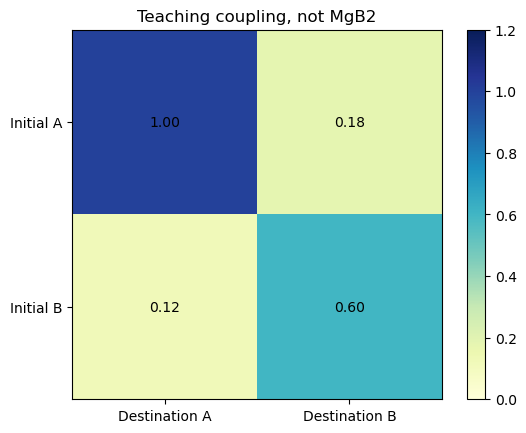

In [2]:
weighted = model.weights[:, None]*model.lambda_matrix
assert np.allclose(weighted, weighted.T)
print('Reciprocity:', weighted[0, 1], weighted[1, 0])
print('Row couplings:', model.lambda_matrix.sum(axis=1))
print('FS average:', model.average_lambda)
assert abs(model.average_lambda-.904) < 1e-14
assert not np.allclose(model.lambda_matrix, model.lambda_matrix.T)
plt.imshow(model.lambda_matrix, cmap='YlGnBu', vmin=0, vmax=1.2)
for i in range(2):
    for j in range(2):
        plt.text(j, i, f'{model.lambda_matrix[i,j]:.2f}', ha='center', va='center', color='black')
plt.xticks([0, 1], ['Destination A', 'Destination B'])
plt.yticks([0, 1], ['Initial A', 'Initial B'])
plt.title('Teaching coupling, not MgB2'); plt.colorbar(); plt.show()

## 3. 用有符号频率独立核对正常项
正常项负频率改变分子符号；配对项偶频，因此核相加，库仑项乘 2。
这里不调用折叠核实现，重新构造完整 2N 频率求和。

In [3]:
T = 5.
w, z, matrix = linearized(T, model)
signed = np.r_[-w[::-1], w]
z_signed = np.ones_like(z)
for i in range(2):
    for n, wn in enumerate(w):
        for j in range(2):
            k = model.lambda_matrix[i,j]*100/(100+(wn-signed)**2)
            z_signed[i,n] += np.pi*KB_MEV_K*T/wn*np.sum(k*np.sign(signed))
print('Folded vs signed Z error:', np.max(abs(z-z_signed)))
assert np.max(abs(z-z_signed)) < 1e-13
assert matrix.shape == (192, 192)

Folded vs signed Z error: 8.881784197001252e-16


## 4. 单带极限
相同未加权 V 的每行和相等。把相同频率向量嵌入两带检查 B 的索引。

In [4]:
one = Model([1], [[.904]], [[.1]])
equal_rows = Model([.4, .6], np.full((2, 2), .904), np.full((2, 2), .1))
_, z1, b1 = linearized(6, one)
_, z2, b2 = linearized(6, equal_rows)
v = np.sin(np.arange(96)+.2)
error = np.max(abs(b2@np.tile(v, 2)-np.tile(b1@v, 2)))
print('Single-band embedding error:', error)
assert error < 1e-13 and np.max(abs(z2-z1)) < 1e-13

Single-band embedding error: 1.1102230246251565e-16


## 5. 最大实本征值达到 1
先检验低温/高温端，再二分。区间宽度不是物理误差棒。
同平均 λ 的各向同性模型不同于双带解，不是普适 Tc 增强定理。

In [5]:
tc = find_tc(2, 25, model)
tc_iso = find_tc(2, 25, one)
print('Two-band finite Tc:', tc['lower_K'], tc['upper_K'])
print('Same-average isotropic Tc:', tc_iso['lower_K'], tc_iso['upper_K'])
assert instability(tc['lower_K'], model)['eigenvalue'] > 1
assert instability(tc['upper_K'], model)['eigenvalue'] <= 1
assert tc['upper_K']-tc['lower_K'] <= .01
assert not tc['is_material_prediction'] and not tc['matsubara_cutoff_converged']

Two-band finite Tc: 10.091552734375 10.09716796875
Same-average isotropic Tc: 7.879150390625 7.884765625


## 6. 4 K 非线性虚轴函数
原方程残差，而非混合步长。Δ(iw₀) 不等于实轴实验能隙。
连通分组分别初始化，不能让完全解耦的不稳定带留在零解。

Delta_A/B(iw0), meV: [1.86537685 0.87471469]
Unmixed residuals: 9.543099421804868e-09 5.226685750869819e-10


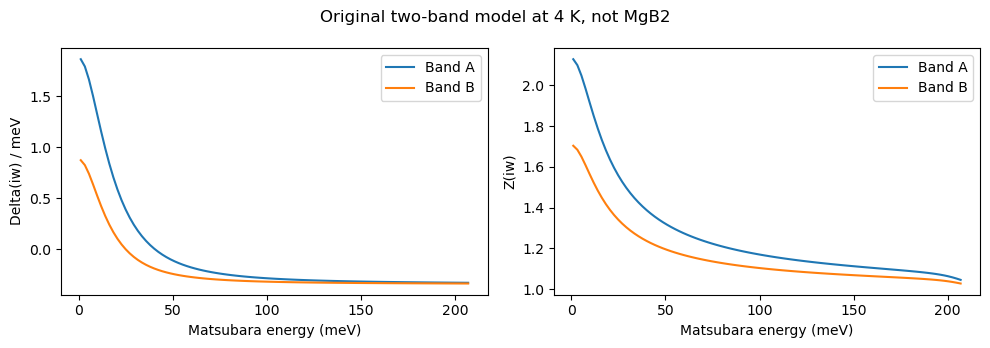

In [6]:
solution = solve_gap(4, model)
normal = solve_gap(20, model)
gap, Z = np.array(solution['gap_meV']), np.array(solution['Z'])
print('Delta_A/B(iw0), meV:', gap[:, 0])
print('Unmixed residuals:', solution['gap_residual_meV'], solution['Z_residual'])
assert solution['gap_residual_meV'] < 1e-8 and solution['Z_residual'] < 1e-9
assert not normal['superconducting'] and np.max(abs(np.array(normal['gap_meV']))) == 0
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
for i in range(2):
    axes[0].plot(solution['frequency_meV'], gap[i], label=f'Band {"AB"[i]}')
    axes[1].plot(solution['frequency_meV'], Z[i], label=f'Band {"AB"[i]}')
axes[0].set(xlabel='Matsubara energy (meV)', ylabel='Delta(iw) / meV')
axes[1].set(xlabel='Matsubara energy (meV)', ylabel='Z(iw)')
for ax in axes: ax.legend()
fig.suptitle('Original two-band model at 4 K, not MgB2'); plt.tight_layout(); plt.show()

## 7. 读固定温度演示，并核对来源
温度是物理变量，不是 DFT 收敛参数。接近 Tc 的 10 K 演示用 10000 步预算。
此处读已有模型报告，不下载作者数据。检查 4 K 的记录与刚刚计算的解一致。

2.0 [1.92721 0.96033] 142
4.0 [1.86538 0.87471] 162
6.0 [1.70548 0.67514] 163
8.0 [1.3414 0.4229] 332
9.0 [1.01679 0.2894 ] 561
10.0 [0.30495 0.0789 ] 4923
10.09716796875 [0. 0.] 1
12.0 [0. 0.] 1
15.0 [0. 0.] 1
20.0 [0. 0.] 1


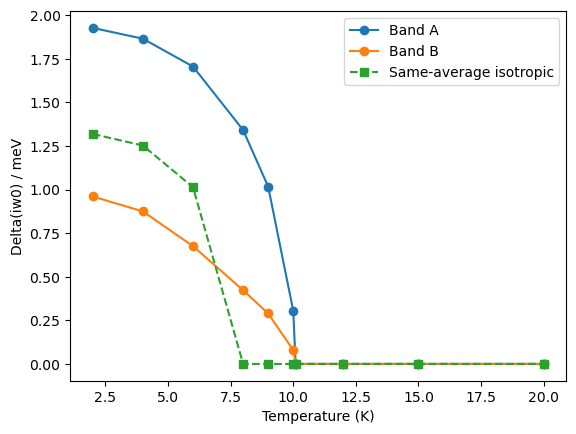

In [7]:
report = json.loads((Path.cwd()/'results/validation.json').read_text(encoding='utf-8'))
rows = report['temperature_results']
at4 = next(row for row in rows if row['T_K'] == 4)
assert np.allclose(at4['band_gap_iw0_meV'], gap[:,0], atol=1e-10)
assert all(row['gap_residual_meV'] < 1e-8 for row in rows)
for row in rows:
    print(row['T_K'], np.round(row['band_gap_iw0_meV'], 5), row['iterations'])
ts = [row['T_K'] for row in rows]
for i in range(2):
    plt.plot(ts, [row['band_gap_iw0_meV'][i] for row in rows], 'o-', label=f'Band {"AB"[i]}')
plt.plot(ts, [row['isotropic_gap_iw0_meV'] for row in rows], 's--', label='Same-average isotropic')
plt.xlabel('Temperature (K)'); plt.ylabel('Delta(iw0) / meV'); plt.legend(); plt.show()
assert report['scope']['new_cluster_jobs'] == 0
assert not report['scope']['is_paper_figure_reproduction']

## 8. 自动验收与原图边界
运行独立测试：全正负求和、截止跨越、互易、单带极限、标签交换、解耦与残差。
论文目标是作者稿 p10 Fig. 6(a)，不是把本图曲线改成 σ/π 标签。

In [8]:
import test_two_band
suite = unittest.defaultTestLoader.loadTestsFromModule(test_two_band)
stream = io.StringIO()
result = unittest.TextTestRunner(stream=stream, verbosity=0).run(suite)
print(stream.getvalue())
assert result.wasSuccessful() and result.testsRun == 19
manifest = json.loads((Path.cwd()/'source_manifest.json').read_text(encoding='utf-8'))
print('Read source:', manifest['paper']['read_version'])
print('Original figure data acquired: NO. Original model output is NOT paper reproduction.')

----------------------------------------------------------------------
Ran 19 tests in 0.080s

OK

Read source: arXiv:1211.3345v1 (2012-11-14), 13 pages
Original figure data acquired: NO. Original model output is NOT paper reproduction.


## 课后提交
手算 p_Aλ_AB=p_Bλ_BA；推导折叠；说明单带矩阵嵌入；解释临界慢化。
再写一段本模型与 Fig. 6(a) 的三项差异，以及真正定量复现需要的输入。
参见仓库中文教程、原文对照与 MgB₂ 复现任务单。